In [15]:
import matplotlib.pyplot as plt
import h5py
import numpy as np

In [2]:
plt.style.use("paper.mplstyle")

In [53]:
Original_HV = "../Files/HDFINJFIND_HLV_HV_original.hdf"
Modified_HV = "../Files/HDFINJFIND_HLV_HV_modified.hdf"
Flow_HV = "../Files/HDFINJFIND_HLV_HV_flow.hdf"
Original_HL = "../Files/HDFINJFIND_HLV_HL_original.hdf"
Modified_HL = "../Files/HDFINJFIND_HLV_HL_modified.hdf"
Flow_HL = "../Files/HDFINJFIND_HLV_HL_flow.hdf"
Original_LV = "../Files/HDFINJFIND_HLV_LV_original.hdf"
Modified_LV = "../Files/HDFINJFIND_HLV_LV_modified.hdf"
Flow_LV = "../Files/HDFINJFIND_HLV_LV_flow.hdf"
Original_LV = "../Files/HDFINJFIND_HLV_LV_original.hdf"
Modified_LV = "../Files/HDFINJFIND_HLV_LV_modified.hdf"
Flow_LV = "../Files/HDFINJFIND_HLV_LV_flow.hdf"
Original_2DET = "../Files/HDFINJFIND_HLV_LV_original.hdf"
Modified_2DET = "../Files/HDFINJFIND_HLV_LV_modified.hdf"
Flow_2DET = "../Files/HDFINJFIND_HLV_LV_flow.hdf"
Files = [Original_HL, Modified_HL, Flow_HL,Original_HV, Modified_HV, Flow_HV,Original_LV, Modified_LV, Flow_LV,Original_2DET, Modified_2DET, Flow_2DET]


In [54]:
def chirp_mass(m1, m2):
    return (m1 * m2)**(3.0/5.0) / (m1 + m2)**(1.0/5.0)

In [55]:
def load_injection_data(h5, ifar_thresh):
    m1 = h5["injections/mass1"][:]
    m2 = h5["injections/mass2"][:]
    mc = chirp_mass(m1, m2)

    inj_idx = h5["found/injection_index"][:]
    ifar = h5["found/ifar_exc"][:]

    found_mask = ifar >= ifar_thresh
    inj_idx_found = inj_idx[found_mask]

    mc_found = mc[inj_idx_found]

    return mc, mc_found

In [56]:
chirp_bins = [
        (0.8, 2.5),
        (2.5, 20.0),
        (20.0, 50.0),
        (50.0, 1000.0),
    ]
    
bin_labels = [f"{lo}-{hi}" for lo, hi in chirp_bins]

In [57]:
all_totals = []
all_found = []
all_frac = []

for fpath in Files:
    with h5py.File(fpath, "r") as h5:
        mc_total, mc_found = load_injection_data(h5, 0.5)

    totals = []
    found = []
    frac = []

    for lo, hi in chirp_bins:
        t = np.sum((mc_total >= lo) & (mc_total < hi))
        f = np.sum((mc_found >= lo) & (mc_found < hi))
        totals.append(t)
        found.append(f)
        print(np.sum(found))
        frac.append(f / t if t > 0 else np.nan)

    all_totals.append(totals)
    all_found.append(found)
    all_frac.append(frac)

229
2093
9375
19129
228
2093
9377
19189
228
2092
9404
19236
19
239
1385
2757
19
240
1379
2735
20
248
1456
2912
20
214
1385
2709
19
215
1384
2708
21
228
1463
2908
20
214
1385
2709
19
215
1384
2708
21
228
1463
2908


In [58]:
x=np.arange(len(chirp_bins))

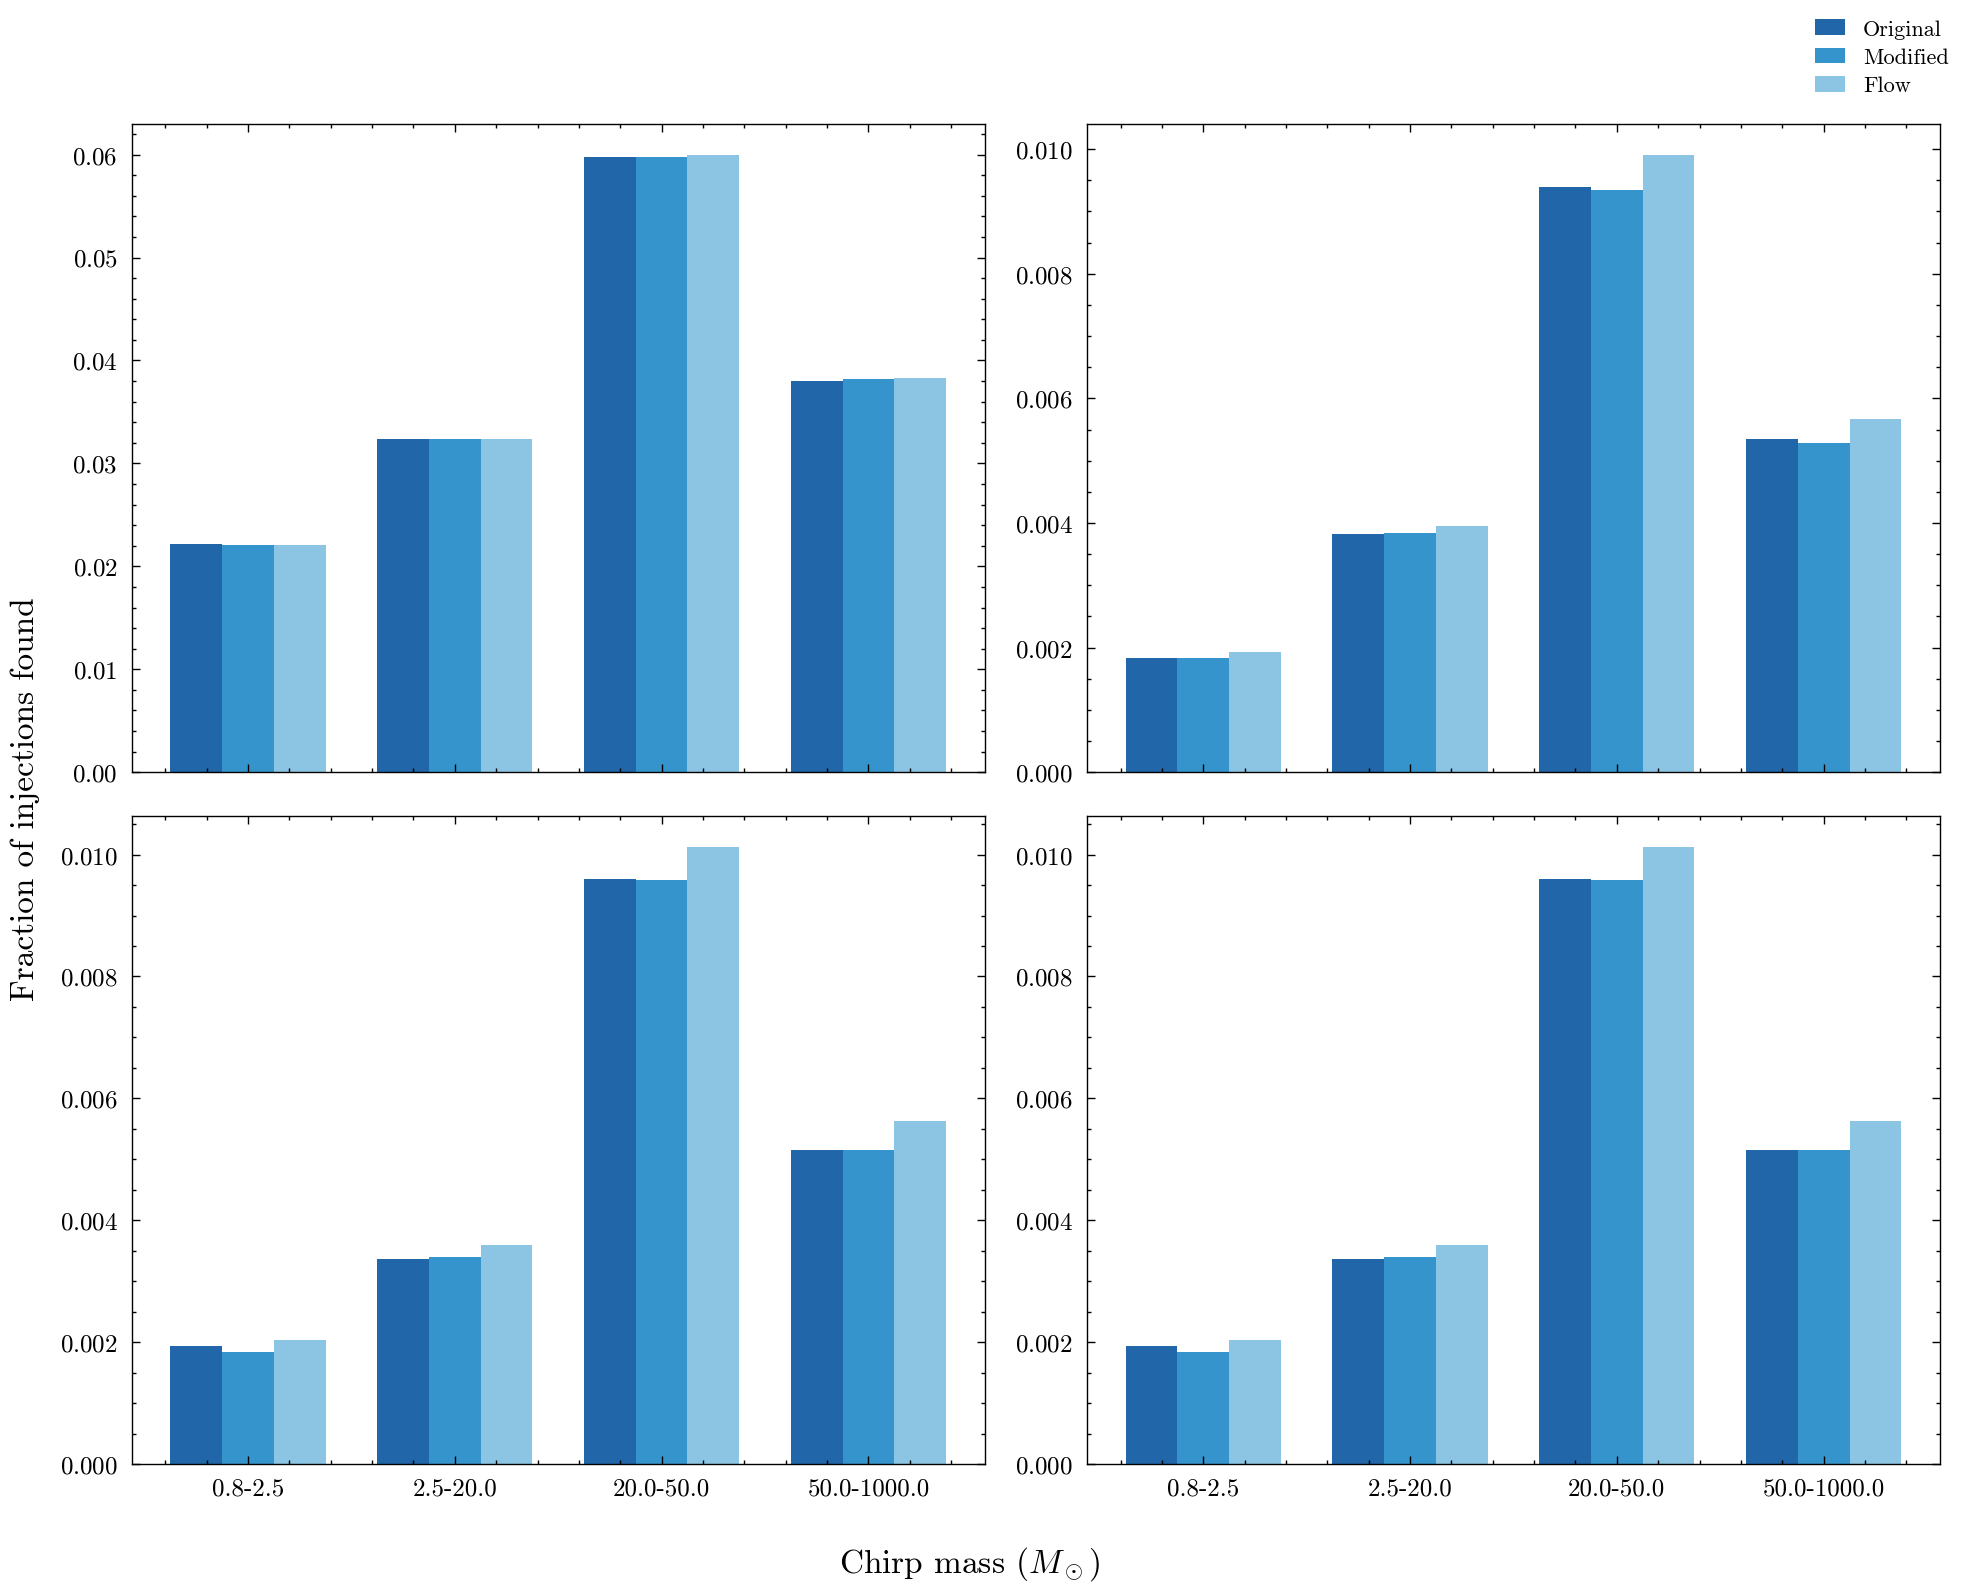

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

x = np.arange(len(chirp_bins))
width = 0.25

colors = {
    "Original": "#2066a8",
    "Modified": "#3594cc",
    "Flow":     "#8cc5e3",
}


for i, ax in enumerate(axes.flat):
    base = 3 * i 

    ax.bar(x - width, all_frac[base + 0], width,
           label="Original", color=colors["Original"])
    ax.bar(x,         all_frac[base + 1], width,
           label="Modified", color=colors["Modified"])
    ax.bar(x + width, all_frac[base + 2], width,
           label="Flow", color=colors["Flow"])

    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)


fig.supxlabel(r"Chirp mass ($M_\odot$)")
fig.supylabel("Fraction of injections found")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../Plots/2DET_summary.png")
plt.show()